# Direct Wind Magnet Layout:

## Manual Setup Version:

In [ ]:
%%time
import numpy as np
from iminuit import Minuit
from iminuit.cost import UnbinnedNLL
from scipy.stats import norm
import panel as pn
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
# Sets the floats to round instead of going into scientific notation
np.set_printoptions(suppress=True, formatter={'float_kind':'{:0.6f}'.format})

# =============== Function definitions ===============

# Need to be able to do this for mutiple groups, so different angular bounds at same rad
def plotter(lower, upper, rad, point_num): # Need to find a way to not have them evenly dispersed through the radius, need them side-by-side
    # Iterate through lower and upper angle bounds, with some dphi that determines the spacing
    phi_list = np.linspace(np.deg2rad(lower), np.deg2rad(upper), point_num) # Enter in degrees
    x = rad*np.cos(phi_list)
    y = rad*np.sin(phi_list)
    return x, y

def circ_plot(rad, color='k--'):
    circ = np.linspace(0, 2*np.pi, 500)
    x = rad * np.cos(circ)
    y = rad * np.sin(circ)
    plt.plot(x, y, color, zorder=1)

# The field defined in terms of the harmonics
def B_harm(x, y, x_a, y_a, I):
    # Position of the conductor
    a = np.hypot(x_a, y_a)
    
    # Position of field measurement
    r = np.hypot(x, y)

    # Angle between a and y=0
    phi = np.arctan2(y_a, x_a)
    # Angle between r and y=0
    theta = np.arctan2(y, x)

    # Angle between r and a
    ang = phi - theta

    # Replace r=0 with r=1e-20 to avoid divsion by zero
    r = np.where(r == 0, 1e-10, r)

    # Now we compute the field for both cases, adding up harmonics until the n_max harmonic is calculated and added

    # Case for r < a:
    B_r_in = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(r / a)**(n - 1) * np.sin(n * ang) for n in range(1, n_max+1)], axis=0)
    B_theta_in = (-1)*((mu0 * I) / (2 * np.pi * a)) * np.sum([(r / a)**(n - 1) * np.cos(n * ang) for n in range(1, n_max+1)], axis=0)
    
    # Case for r > a:
    B_r_out = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(a / r)**(n + 1) * np.sin(n * ang) for n in range(0, n_max+1)], axis=0)
    B_theta_out = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(a / r)**(n + 1) * np.cos(n * ang) for n in range(0, n_max+1)], axis=0)

    # Use np.where to select the correct field values to return
    # np.where(cond., x, y) -> If true, takes x; if false, takes y
    B_r = np.where(r > a, B_r_out, B_r_in)
    B_theta = np.where(r > a, B_theta_out, B_theta_in)

    # Convert to cartesian coordinates (notably using the angle theta, not ang)
    B_x = B_r * np.cos(theta) - B_theta * np.sin(theta)
    B_y = B_r * np.sin(theta) + B_theta * np.cos(theta)

    return B_x, B_y

# To calculate the individual harmonic at ref_rad (R0) due to a conductor with current I at position (a, phi)
# Poles go by (n+1), so n=2 -> 3phi -> Sextupole
# 0 = Dipole, 1=Quadrupole, 2=Sextupole, etc.
# For a dipole, even harmonics are not allowed, so here we just look at odd constributions
def Harmonic(R0, a, phi, n, I_wire):
    return (mu0*I_wire/2*np.pi) * (10**4) * ((R0 / a)**n) * np.cos((n + 1) * phi)


# =============== User defined varaiables ===============

# Max n values for field calculation
n_max = 10
# Radius of aperture
aper_rad = 2 
# Min angle from the x-axis for the first block in each layer
min_ang = 20
# Radial spacing
dr = 0.1 
# Thickness of spacing between layers
t = 0.07 
# Reference radius
ref_rad = 1
# Current magnitude
I0 = 500

# Type of magnet: 1=dipole, 2=quadrupole, 3=sextupole
mag_type = 3

# Set it to only show the surface plot for the field strength along the body of the magnet
surf_plot = False

# To set to either show all quadrants or only the first quadrant here:
all_quads = False

# =============== Defined variables ===============
# Vacuum permeability
mu0 = 4 * np.pi * 1e-7 
# Radius of the first layer, based on aperture radius
init_rad = aper_rad + dr 

# Right now, points are distributed uniformly over the angular region, thus, angular spacing between points is not controlled by the user
# spacing = [ [], [], [] ]
# This contains the dphi for each block
# For n blocks we have n+1 spaces to worry about

"""
TO-DO:
Need to make a function that creates a list of angles based on spacing list
Spacing does not have to be the same for each layer
Each spacing value is a delta phi really
Based on the min angle set above
"""
num_of_layers = 3
spacing = []
#spacing = [[] for i in range(n)] # -> makes a list of [ [], [], [], ..., [] ]

# These are just examples for each of the magnet types
if mag_type == 1:
    # Dipole example:
    layers = [ 
                    [ [10], [ (5, 80) ] ], # Layer 1
                    [ [10], [ (5, 80) ] ], # Layer 2
                    [ [10], [ (5, 80) ] ] # Layer 3
             ]
elif mag_type == 2:
    # Quadrupole example:
    layers = [ 
                    [ [5, 5], [ (3, 20), (70, 87) ] ], # Layer 1
                    [ [5, 5], [ (3, 20), (70, 87) ] ], # Layer 2
                    [ [5, 5], [ (3, 20), (70, 87) ] ] # Layer 3
             ]
elif mag_type == 3:
    # Sextupole example:
    layers = [ 
                    [ [3, 6], [ (3, 13), (50, 70)] ], # Layer 1
                    [ [3, 6], [ (3, 13), (50, 70)] ], # Layer 2
                    [ [3, 6], [ (3, 13), (50, 70)] ] # Layer 3
             ]

# =============== Geomerty calculations ===============

# Arrays of the x and y values per layer
x_quad1 = []
y_quad1 = []

# A list of radii to plot based on the layer spacing:
rads = []
# Loops over each layer
for i, layer in enumerate(layers): # Goes from 1-3
    # Radii at which points are plotted, depends only on the layer we are on
    rads.append(init_rad+(2*i*dr) + (i+1)*t) 
    # Loops over the second list in each layer
    for j, ang_list in enumerate(layer[1]):
        # Calulates the x and y values of each conductor for that blocks given angles
        # Accounts for the spacing between the layers, layer[0][j] is the number of conductors
        # x and y are the give an array of coordinates for each conductor in the block
        x, y = plotter(ang_list[0], ang_list[1], init_rad+(2*i*dr) + (i+1)*t, layer[0][j])  
        x_quad1.append(x)
        y_quad1.append(y)


# Concatenation puts them all into just one list
# Concatenated list is still in block order
x_totq1 = np.concatenate(x_quad1)
y_totq1 = np.concatenate(y_quad1)

# Reflect values to each quadrant:
# Q2 
x_totq2 = -1*x_totq1
y_totq2 = y_totq1
# Q3
x_totq3 = -1*x_totq1
y_totq3 = -1*y_totq1
# Q4
x_totq4 = x_totq1
y_totq4 = -1*y_totq1
# Concatenate all these lists to make a total list of x and y values
x_tot = np.concatenate( (x_totq1, x_totq2, x_totq3, x_totq4) )
y_tot = np.concatenate( (y_totq1, y_totq2, y_totq3, y_totq4) )


print(f"Radii of Condutor Layers: {[round(r, 2) for r in rads]}")

# Shows all quadrants or only 1st quadrant based on setting above:
if all_quads:
    # Bounds for all four quadrants:
    bounds =  [ [-3, 3], [-3, 3] ]
elif not all_quads:
    # Bounds for first quadrant only:
    bounds =  [ [0, 3], [0, 3] ]


# =============== Magnetic Field & Harmonic calculations ===============

# Grid setup (for plotting the field)
# The field is always calculated everywhere in this region
x = np.linspace(bounds[0][0], bounds[0][1], 250)
y = np.linspace(bounds[1][0], bounds[1][1], 250)
X, Y = np.meshgrid(x, y)

Bx_total = np.zeros_like(X)
By_total = np.zeros_like(Y)

# Here we caluclate the harmonic components for each n in n_list witin the given ref_rad
n_list = [0, 1, 2, 3, 4]  # dipole, quadrupole, sextupole, octupole, deacpole, etc.

 # From the magtype definition, sets main field to whatever the magnet type is set to
B_main_index = mag_type - 1

# Initializing harmonics array
# Need to intialize to add to the initial zero, otherwise throws an error
harms = np.zeros(len(n_list)) 

# Assigns currents based on magnet type
# Uses cos theta for dipole to change sign
# Uses cos 2theta for quadrupole to change sign
# Uses cos 3theta for sextupole to change sign
# etc.
for xa, ya in zip(x_tot, y_tot):
    phi = np.arctan2(ya, xa)
    a   = np.hypot(xa, ya)
    # Check the sign of cosine to determine the sign of the current
    if np.cos(mag_type*phi) >= 0:
        I = I0
    else:
        I=-I0

    Bx, By = B_harm(X, Y, xa, ya, I)
    if surf_plot == True:
        pass
    else:
        plt.scatter(xa, ya, c=("red" if I >= 0 else "blue"))

    Bx_total += Bx
    By_total += By

    # Calculates the harmonic contribution due to the current conductor
    for j, n_val in enumerate(n_list):
        harms[j] += Harmonic(ref_rad, a, phi, n_val, I)  # Sign of current matters
    
# Total B-field magnitudes are computed
B_mag = np.hypot(Bx_total, By_total)

print("Harmonics [n=0,dipole, n=1,quad, n=2,sext, n=3,oct, n=4,deca]:", harms)
print("Relative to main:", harms / (harms[B_main_index] if harms[B_main_index] != 0 else 1))

# convert to 10^4 units relative to main multipole:
B_main = harms[B_main_index]  # for dipole magnet, n=0 is main
units = (harms / B_main) * 1e4
print("Harmonics in 10^4 units:", units)



# =============== Magnetic Field & Harmonic calculations ===============

if surf_plot == True:
    fig, ax = plt.subplots(figsize=(6,6))
    mask = (X**2 + Y**2 >= aper_rad**2) & (X**2 + Y**2 <= (rads[-1]+dr)**2)
    B_mag_masked = np.where(mask, B_mag, np.nan)
    
    # Create the surface plot (can switch to B_mag_masked)
    pcm = ax.pcolormesh(X, Y, B_mag_masked, shading='auto', cmap='viridis')
    fig.colorbar(pcm, ax=ax, label='Magnetic Field Magnitude (T)')
else:
    # Plots the magnetic field lines
    strm = plt.streamplot(X, Y, Bx_total, By_total, color=B_mag, cmap='viridis', density=3, zorder=0)
    cbar = plt.colorbar(strm.lines, label='Magnetic Field Magnitude (T)')

# Plots circles around \pm dr awway from where the conductors are (offset by t as done above)
for rad in rads:
    circ_plot(rad+dr)
    circ_plot(rad-dr)

# Aperture Radius
circ_plot(aper_rad, color='k:')
# Reference Radius
circ_plot(ref_rad, color='k:')



# ========== USER INPUTS ==========
theta_rad = np.pi/(2*mag_type)  # angle spacing in degrees -> This layout is what we want to copy
r = 5           # length of each line
# =================================

# Plot lines every theta_deg degrees
for i in range(int(2*np.pi / theta_rad)):
    angle = i * theta_rad
    x = [0, r * np.cos(angle)]
    y = [0, r * np.sin(angle)]
    plt.plot(x, y, 'r--', lw=1)

# Draw a reference circle
circ = np.linspace(0, 2*np.pi, 500)
plt.plot(r * np.cos(circ), r * np.sin(circ), 'b:')



plt.xlim(bounds[0][0], bounds[0][1])
plt.ylim(bounds[1][0], bounds[1][1])
plt.xlabel("x")
plt.ylabel("y")
plt.axhline(0, color='black', linewidth=1, zorder=1)
plt.axvline(0, color='black', linewidth=1, zorder=1)
plt.gca().set_aspect('equal')
plt.show()

## Plotting With Proper Spacing:

In this version, we define the spacing from the x-axis for each block. We also show the symmetry lines, depending on the magnet type.

In [ ]:
%%time
import numpy as np
from iminuit import Minuit
from iminuit.cost import UnbinnedNLL
from scipy.stats import norm
import panel as pn
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
# Sets the floats to round instead of going into scientific notation
np.set_printoptions(suppress=True, formatter={'float_kind':'{:0.6f}'.format})

# =============== Function definitions ===============

# Need to be able to do this for mutiple groups, so different angular bounds at same rad

"""
Spacing list is really just a list of angles like before
Spacing (in its current form of 11/5/25) is a list of minor anlges that blocks start at, but this works
"""

# Converts the defined mm value for point radius to s value to be plotted
def mm_to_s(r_mm):
    """Convert marker radius in millimeters to Matplotlib scatter size (s in pt²)."""
    return np.pi * (r_mm / 0.3528)**2

def plotter(spacing, rad, point_num): # Need to find a way to not have them evenly dispersed through the radius, need them side-by-side
    # Iterate through lower and upper angle bounds, with some dphi that determines the spacing

    # Default size of a point
    point_rad = 0.0785 # Default radius of plt.scatter points in data units
    delta_phi_block = (point_num*2*point_rad)/(rad)

    lower = np.deg2rad(spacing)
    upper = delta_phi_block + lower

    
    phi_list = np.linspace(lower, upper, point_num) # Enter in degrees ?
    x = rad*np.cos(phi_list)
    y = rad*np.sin(phi_list)
    return x, y

def circ_plot(rad, color='k--'):
    circ = np.linspace(0, 2*np.pi, 500)
    x = rad * np.cos(circ)
    y = rad * np.sin(circ)
    plt.plot(x, y, color, zorder=1)

# The field defined in terms of the harmonics
def B_harm(x, y, x_a, y_a, I):
    # Position of the conductor
    a = np.hypot(x_a, y_a)
    
    # Position of field measurement
    r = np.hypot(x, y)
    # Replace r=0 with r=1e-20 to avoid divsion by zero
    r = np.where(r == 0, 1e-10, r)

    # Angle between a and y=0
    phi = np.arctan2(y_a, x_a)
    # Angle between r and y=0
    theta = np.arctan2(y, x)

    # Angle between r and a
    ang = phi - theta

    # Now we compute the field for both cases, adding up harmonics until the n_max harmonic is calculated and added

    # Case for r < a:
    B_r_in = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(r / a)**(n - 1) * np.sin(n * ang) for n in range(1, n_max+1)], axis=0)
    B_theta_in = (-1)*((mu0 * I) / (2 * np.pi * a)) * np.sum([(r / a)**(n - 1) * np.cos(n * ang) for n in range(1, n_max+1)], axis=0)
    
    # Case for r > a:
    B_r_out = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(a / r)**(n + 1) * np.sin(n * ang) for n in range(0, n_max+1)], axis=0)
    B_theta_out = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(a / r)**(n + 1) * np.cos(n * ang) for n in range(0, n_max+1)], axis=0)

    # Use np.where to select the correct field values to return
    # np.where(cond., x, y) -> If true, takes x; if false, takes y
    B_r = np.where(r > a, B_r_out, B_r_in)
    B_theta = np.where(r > a, B_theta_out, B_theta_in)

    # Convert to cartesian coordinates (notably using the angle theta, not ang)
    B_x = B_r * np.cos(theta) - B_theta * np.sin(theta)
    B_y = B_r * np.sin(theta) + B_theta * np.cos(theta)

    return B_x, B_y

# To calculate the individual harmonic at ref_rad (R0) due to a conductor with current I at position (a, phi)
# Poles go by (n+1), so n=2 -> 3phi -> Sextupole
# 0 = Dipole, 1=Quadrupole, 2=Sextupole, etc.
# For a dipole, even harmonics are not allowed, so here we just look at odd constributions
def Harmonic(R0, a, phi, n, I_wire):
    return (mu0*I_wire/2*np.pi) * (10**4) * ((R0 / a)**n) * np.cos((n + 1) * phi)


# =============== User defined varaiables ===============

# Max n values for field calculation
n_max = 10
# Radius of aperture
aper_rad = 2 
# Min angle from the x-axis for the first block in each layer
min_ang = 20
# Radial spacing
dr = 0.1 
# Thickness of spacing between layers
t = 0.07 
# Reference radius
ref_rad = 1
# Current magnitude
I0 = 500
# Radius of points in mm
r_mm = 1.5
# Radius of points converted to s units
s_size = mm_to_s(r_mm)

# Type of magnet: 1=dipole, 2=quadrupole, 3=sextupole
mag_type = 3

# Set it to only show the surface plot for the field strength along the body of the magnet
surf_plot = False

# To set to either show all quadrants or only the first quadrant here:
all_quads = True

# =============== Defined variables ===============
# Vacuum permeability
mu0 = 4 * np.pi * 1e-7 
# Radius of the first layer, based on aperture radius
init_rad = aper_rad + dr 

# Right now, points are distributed uniformly over the angular region, thus, angular spacing between points is not controlled by the user
# spacing = [ [], [], [] ]
# This contains the dphi for each block
# For n blocks we have n+1 spaces to worry about

"""
TO-DO:
Need to make a function that creates a list of angles based on spacing list
Spacing does not have to be the same for each layer
Each spacing value is a delta phi really
Based on the min angle set above
"""
num_of_layers = 3
spacing = []
#spacing = [[] for i in range(n)] # -> makes a list of [ [], [], [], ..., [] ]

# These are just examples for each of the magnet types

"""
What we really need here is to have the angles automatically calibrated based on the number of conductors, 
so that the conductors just layout so that they are adjacent
What we really want is the ability to vary the spacing

We can just replace the angle tuple with a spacing tuple that contains all the delta phis

The offset for each block can be calculated from the other angles in the list and the number of conductors

DO THIS TEST:
- Add the spaces and the angles the conductors take up, and see if 


Now, spacing works, but it is spacing from x-axis

"""


# Old Dipole layer
"""
    layers = [ 
                    [ [10], [ (5, 80) ] ], # Layer 1
                    [ [10], [ (5, 80) ] ], # Layer 2
                    [ [10], [ (5, 80) ] ] # Layer 3
             ]
"""



# TEST CASES:
if mag_type == 1:
    # Dipole example:
    layers = [ 
        [ [15], [5] ],
        [ [15], [5] ],
        [ [15], [5] ],
        [ [15], [5] ],
        [ [15], [5] ],
        [ [15], [5] ],
        [ [15], [5] ],
        [ [15], [5] ]
             ]


elif mag_type == 2:
    # Quadrupole example:
    layers = [ 
        [ [3,3], [10,70] ], # Layer 1
        [ [3,3], [10,70] ], 
        [ [3,3], [10,70] ], 
        [ [3,3], [10,70] ], 
        [ [3,3], [10,70] ], 
        [ [3,3], [10,70] ], 
        [ [3,3], [10,70] ], 
        [ [3,3], [10,70] ] 
             ]

# Not correct configuration
elif mag_type == 3:
    # Sextupole example:
    layers = [ 
        [ [3, 6], [3,50] ], # Layer 1
        [ [3, 6], [3,50] ],
        [ [3, 6], [3,50] ],
        [ [3, 6], [3,50] ],
        [ [3, 6], [3,50] ]
             ]

""" 
New Layer layout:

layers = [
    [ [3, 3], [space1a, space2a, space3a] ],
    [ [3, 3], [space1b, space2b, space3b] ]
]

layers[layer][0 = cond_nums, 1 = spacing][i]
"""

# =============== Geomerty calculations ===============

# Arrays of the x and y values per layer
x_quad1 = []
y_quad1 = []


"""
    # Loops over the second list in each layer
    for j, ang_list in enumerate(layer[1]):
        # Calulates the x and y values of each conductor for that blocks given angles
        # Accounts for the spacing between the layers, layer[0][j] is the number of conductors
        # x and y are the give an array of coordinates for each conductor in the block
        x, y = plotter(ang_list[0], ang_list[1], init_rad+(2*i*dr) + (i+1)*t, layer[0][j])  
        x_quad1.append(x)
        y_quad1.append(y)
"""

# A list of radii to plot based on the layer spacing:
rads = []
# Loops over each layer
for i, layer in enumerate(layers): # Goes from 1-3
    # Radii at which points are plotted, depends only on the layer we are on
    rads.append(init_rad+(2*i*dr) + (i+1)*t) 
    # Loops over the second list in each layer
    # Iterates over each spacing value
    for j, space in enumerate(layer[1]):
        # Calulates the x and y values of each conductor for that blocks given angles
        # Accounts for the spacing between the layers
        # x and y are the give an array of coordinates for each conductor in the block
        # layers[i][0][j] is the number of conductors for the current layer, and it loops through this
        # list and it plots for the specified number
        x, y = plotter(space, init_rad+(2*i*dr) + (i+1)*t, layers[i][0][j])  
        x_quad1.append(x)
        y_quad1.append(y)
        

# Concatenation puts them all into just one list
# Concatenated list is still in block order
x_totq1 = np.concatenate(x_quad1)
y_totq1 = np.concatenate(y_quad1)

# Reflect values to each quadrant:
# Q2 
x_totq2 = -1*x_totq1
y_totq2 = y_totq1
# Q3
x_totq3 = -1*x_totq1
y_totq3 = -1*y_totq1
# Q4
x_totq4 = x_totq1
y_totq4 = -1*y_totq1
# Concatenate all these lists to make a total list of x and y values
x_tot = np.concatenate( (x_totq1, x_totq2, x_totq3, x_totq4) )
y_tot = np.concatenate( (y_totq1, y_totq2, y_totq3, y_totq4) )


print(f"Radii of Conductor Layers: {[round(r, 2) for r in rads]}")

# Last value in the rads list:
max_rad = rads[-1]
max_bound = max_rad + 0.5
# Shows all quadrants or only 1st quadrant based on setting above:
if all_quads:
    # Bounds for all four quadrants:
    bounds =  [ [(-1*max_bound), max_bound], [(-1*max_bound), max_bound] ]
elif not all_quads:
    # Bounds for first quadrant only:
    bounds =  [ [0, max_bound], [0, max_bound] ]


# =============== Magnetic Field & Harmonic calculations ===============

# Grid setup (for plotting the field)
# The field is always calculated everywhere in this region
x = np.linspace(bounds[0][0], bounds[0][1], 250)
y = np.linspace(bounds[1][0], bounds[1][1], 250)
X, Y = np.meshgrid(x, y)

Bx_total = np.zeros_like(X)
By_total = np.zeros_like(Y)

# Here we caluclate the harmonic components for each n in n_list witin the given ref_rad
n_list = [0, 1, 2, 3, 4]  # dipole, quadrupole, sextupole, octupole, deacpole, etc.

 # From the magtype definition, sets main field to whatever the magnet type is set to
B_main_index = mag_type - 1

# Initializing harmonics array
# Need to intialize to add to the initial zero, otherwise throws an error
harms = np.zeros(len(n_list)) 

# Assigns currents based on magnet type
# Uses cos theta for dipole to change sign
# Uses cos 2theta for quadrupole to change sign
# Uses cos 3theta for sextupole to change sign
# etc.
for xa, ya in zip(x_tot, y_tot):
    phi = np.arctan2(ya, xa)
    a   = np.hypot(xa, ya)
    # Check the sign of cosine to determine the sign of the current
    if np.cos(mag_type*phi) >= 0:
        I = I0
    else:
        I=-I0

    Bx, By = B_harm(X, Y, xa, ya, I)
    if surf_plot == True:
        pass
    else:
        #plt.scatter(xa, ya, c=("red" if I >= 0 else "blue"), s=s_size)
        plt.scatter(xa, ya, c=("red" if I >= 0 else "blue"))

    Bx_total += Bx
    By_total += By

    # Calculates the harmonic contribution due to the current conductor
    for j, n_val in enumerate(n_list):
        harms[j] += Harmonic(ref_rad, a, phi, n_val, I)  # Sign of current matters
    
# Total B-field magnitudes are computed
B_mag = np.hypot(Bx_total, By_total)

# These index values are shifted from the Python index values which start at i=0
print("Harmonics [n=1,dipole, n=2,quad, n=3,sext, n=4,oct, n=5,deca]:", harms)
print("Relative to main:", harms / (harms[B_main_index] if harms[B_main_index] != 0 else 1))

# convert to 10^4 units relative to main multipole:
B_main = harms[B_main_index]  # for dipole magnet, n=0 is main
units = (harms / B_main) * 1e4
print("Harmonics in 10^4 units:", units)



# =============== Magnetic Field & Harmonic calculations ===============

if surf_plot == True:
    fig, ax = plt.subplots(figsize=(6,6))
    mask = (X**2 + Y**2 >= aper_rad**2) & (X**2 + Y**2 <= (rads[-1]+dr)**2)
    B_mag_masked = np.where(mask, B_mag, np.nan)
    
    # Create the surface plot (can switch to B_mag_masked)
    pcm = ax.pcolormesh(X, Y, B_mag_masked, shading='auto', cmap='viridis')
    fig.colorbar(pcm, ax=ax, label='Magnetic Field Magnitude (T)')
else:
    # Plots the magnetic field lines
    strm = plt.streamplot(X, Y, Bx_total, By_total, color=B_mag, cmap='viridis', density=3, zorder=0)
    cbar = plt.colorbar(strm.lines, label='Magnetic Field Magnitude (T)')

# Plots circles around \pm dr awway from where the conductors are (offset by t as done above)
for rad in rads:
    circ_plot(rad+dr)
    circ_plot(rad-dr)

# Aperture Radius
circ_plot(aper_rad, color='k:')
# Reference Radius
circ_plot(ref_rad, color='k:')



theta_rad = np.pi/(2*mag_type)*2  # angle spacing in degrees -> This layout is what we want to copy
r = 5           # length of each line

# Plot lines every theta_deg degrees
for i in range(int(2*np.pi / theta_rad)):
    angle = i * theta_rad
    x = [0, r * np.cos(angle)]
    y = [0, r * np.sin(angle)]
    plt.plot(x, y, 'r--', lw=1)

# Draw a reference circle
circ = np.linspace(0, 2*np.pi, 500)
plt.plot(ref_rad * np.cos(circ), ref_rad * np.sin(circ), 'k:')



plt.xlim(bounds[0][0], bounds[0][1])
plt.ylim(bounds[1][0], bounds[1][1])
plt.xlabel("x")
plt.ylabel("y")
plt.axhline(0, color='black', linewidth=1, zorder=1)
plt.axvline(0, color='black', linewidth=1, zorder=1)
plt.gca().set_aspect('equal')
plt.show()

## Angle Mirroring:

Radii of Conductor Layers: [0.21, 0.23]
Harmonics [n=1,dipole, n=2,quad, n=3,sext, n=4,oct, n=5,deca]: [-0.0000000000 0.0000000000 178.6713696127 -0.0000000000 -0.0000000000]
Relative to main: [-0.0000000000 0.0000000000 1.0000000000 -0.0000000000 -0.0000000000]
Harmonics in 10^4 units: [-0.0000000000 0.0000000000 10000.0000000000 -0.0000000000 -0.0000000000]
Aper Radius test:
0.203
0.2


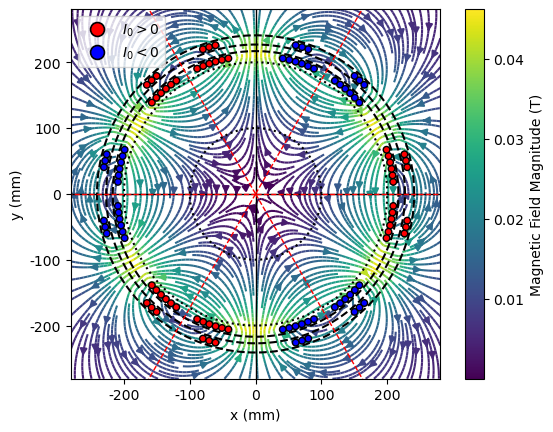

CPU times: total: 15.5 s
Wall time: 15.6 s


In [2]:
%%time

# =============== Imports ===============
import numpy as np
from iminuit import Minuit
from iminuit.cost import UnbinnedNLL
from scipy.stats import norm
import panel as pn
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D

# Sets the floats to round instead of going into scientific notation
np.set_printoptions(suppress=True, formatter={'float_kind':'{:0.10f}'.format})

# =============== Function definitions ===============

# Applies a rotation matrix to points, rotating them over that angle
def rotate_points(x, y, phi):  
    x_rot = x * np.cos(phi) - y * np.sin(phi)
    y_rot = x * np.sin(phi) + y * np.cos(phi)
    return x_rot, y_rot

# Applies a reflection matrix to points, reflecting them over that angle
def reflect_points(x, y, phi):  
    x_ref = x * np.cos(2 * phi) + y * np.sin(2 * phi)
    y_ref = x * np.sin(2 * phi) - y * np.cos(2 * phi)
    return x_ref, y_ref

# Plots conductors over an angular range, starting at some initial angle from x-axis (need to generalize to inter-block spacing)
def plotter(spacing, rad, point_num):

    # Arc length of the conductor block
    delta_phi_block = (point_num*2*wire_rad)/(rad)

    # The lower bound, given by the spacing of the point
    lower = np.deg2rad(spacing)

    # Angle taken up by a single conductor point
    dphi_point = 2 * np.arcsin(wire_rad / rad)

    # linspace evenly distributes points, which is not what we want
    # So we use np.arange, which distributes at a fixed interval
    # Creates a phi list where points are adjacent to eachother
    phi_list = lower + np.arange(point_num) * dphi_point 

    # Converts points to carteisan so that we can plot them
    x = rad*np.cos(phi_list)
    y = rad*np.sin(phi_list)
    return x, y

# Plots a circle given a radius and a color
def circ_plot(rad, color='k--'):
    circ = np.linspace(0, 2*np.pi, 500)
    x = rad * np.cos(circ)
    y = rad * np.sin(circ)
    plt.plot(x, y, color, zorder=1)

# The field defined in terms of the harmonic contributions
def B_harm(x, y, x_a, y_a, I):
    # Position of the conductor
    a = np.hypot(x_a, y_a)
    
    # Position of field measurement
    r = np.hypot(x, y)
    # Replace r=0 with r=1e-20 to avoid divsion by zero
    r = np.where(r == 0, 1e-10, r)

    # Angle between a and y=0
    phi = np.arctan2(y_a, x_a)
    # Angle between r and y=0
    theta = np.arctan2(y, x)

    # Angle between r and a
    ang = phi - theta

    # Now we compute the field for both cases, adding up harmonics until the n_max harmonic is calculated and added

    # Case for r < a:
    B_r_in = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(r / a)**(n - 1) * np.sin(n * ang) for n in range(1, n_max+1)], axis=0)
    B_theta_in = (-1)*((mu0 * I) / (2 * np.pi * a)) * np.sum([(r / a)**(n - 1) * np.cos(n * ang) for n in range(1, n_max+1)], axis=0)
    
    # Case for r > a:
    B_r_out = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(a / r)**(n + 1) * np.sin(n * ang) for n in range(0, n_max+1)], axis=0)
    B_theta_out = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(a / r)**(n + 1) * np.cos(n * ang) for n in range(0, n_max+1)], axis=0)

    # Use np.where to select the correct field values to return
    # np.where(cond., x, y) -> If true, takes x; if false, takes y
    B_r = np.where(r > a, B_r_out, B_r_in)
    B_theta = np.where(r > a, B_theta_out, B_theta_in)

    # Convert to cartesian coordinates (notably using the angle theta, not ang)
    B_x = B_r * np.cos(theta) - B_theta * np.sin(theta)
    B_y = B_r * np.sin(theta) + B_theta * np.cos(theta)

    return B_x, B_y

# To calculate the individual harmonic at ref_rad (R0) due to a conductor with current I at position (a, phi)
# Poles go by (n+1), so n=2 -> 3phi -> Sextupole
# 0 = Dipole, 1=Quadrupole, 2=Sextupole, etc.
# For a dipole, even harmonics are not allowed, so here we just look at odd constributions (example)
def Harmonic(R0, a, phi, n, I_wire):
    return (mu0*I_wire/2*np.pi) * (10**4) * ((R0 / a)**n) * np.cos((n + 1) * phi)


# =============== User defined varaiables ===============\

# Permeability (vaccuum)
mu0 = 4 * np.pi * 1e-7 
# Max n values for field calculation
n_max = 10
# Radius of aperture
aper_rad = 0.2 
# Thickness of spacing between layers
t = 0.01 
# Reference radius
ref_rad = 0.1
# Current magnitude
I0 = 500
# Wire radius in m
wire_rad = 0.005
# Radial spacing
# (0.002 added just to make things more clear on picture)
dr = wire_rad+0.002
# Type of magnet: 1=dipole, 2=quadrupole, 3=sextupole, etc.
mag_type = 3

# Radius of the first layer, based on aperture radius
# Radius at which first layer of conductors lie, hence the plus dr
#init_rad = aper_rad + dr
#init_rad = aper_rad

# =============== Plot settings ===============

# Set it to only show the surface plot for the field strength along the body of the magnet
surf_plot = False
# To set to either show all quadrants or only the first quadrant here:
all_quads = True

# =============== Layer definition ===============

"""
TO-DO:
- Make spacing be between blocks for blocks that are not the first one
- Remove inner wall spacing
- Install checks to make sure conductor blocks are not overlapping and that they are below the symmetry line
- Create a user interface for inputting configuration info
- Find way to optimize spacing
"""

layers = [
    [ [6], [5] ],
    [ [3], [10] ]
]

# =============== Geomerty calculations ===============

# Arrays of the x and y values per layer in quadrant 1
x_quad1 = []
y_quad1 = []

# A list of radii to plot based on the layer spacing:
rads = []
# Loops over each layer
for i, layer in enumerate(layers): # Goes from 1-3
    # Radii at which points are plotted, depends only on the layer we are on
    rads.append(aper_rad + (2*i*dr) + (i+1)*t) 
    # Loops over the second list in each layer
    # Iterates over each spacing value
    for j, space in enumerate(layer[1]):
        # Calulates the x and y values of each conductor for that blocks given angles
        # Accounts for the spacing between the layers
        # x and y are the give an array of coordinates for each conductor in the block
        # layers[i][0][j] is the number of conductors for the current layer, and it loops through this
        # list and it plots for the specified number
        x, y = plotter(space, aper_rad + (2*i*dr) + (i+1)*t, layers[i][0][j])  
        x_quad1.append(x)
        y_quad1.append(y)



# Concatenation puts them all into just one list
# Concatenated list is still in block order
x_totq1 = np.concatenate(x_quad1)
y_totq1 = np.concatenate(y_quad1)


# =============== Symmetry mirroring ===============

# Can use a while loop here too, num_sectors is the flag (?)

# Angular spacing between reset lines (reset angle)
reset_angle = np.pi / mag_type

# Offset to mid-axis in each block (symmetry angle)
reflect_angle = np.pi / (2 * mag_type)

# Total number of angular sectors (i.e. reset angles)
# This is the total amount of times we need to iterate
num_sectors = 2 * mag_type

x_blocks = []  
y_blocks = []  

# Loop over the total number of reset sectors
for j in range(num_sectors): 
    # Starting angle
    block_start = j * reset_angle     
    # Defines the mid-axis to reflect over (starting angle for iteration + reflect angle)
    mid_axis = block_start + reflect_angle   

    # Rotate base pattern over by the block start value angle
    xr, yr = rotate_points(x_totq1, y_totq1, block_start)
    x_blocks.append(xr)                                    
    y_blocks.append(yr)                                    

    # Reflect across mid-axis of this block
    xr_ref, yr_ref = reflect_points(xr, yr, mid_axis)      
    x_blocks.append(xr_ref)                                
    y_blocks.append(yr_ref)                                

# Final conductor positions used everywhere below:
x_tot = np.concatenate(x_blocks) 
y_tot = np.concatenate(y_blocks)

# =============== Geometry checks ===============

print(f"Radii of Conductor Layers: {[round(r, 2) for r in rads]}")

# Last value in the rads list:
max_rad = rads[-1]
max_bound = max_rad*1.2
# Shows all quadrants or only 1st quadrant based on setting above:
if all_quads:
    # Bounds for all four quadrants:
    bounds =  [ [(-1*max_bound), max_bound], [(-1*max_bound), max_bound] ]
elif not all_quads:
    # Bounds for first quadrant only:
    bounds =  [ [0, max_bound], [0, max_bound] ]

# =============== Magnetic Field & Harmonic calculations ===============

# Grid setup (for plotting the field)
# The field is always calculated everywhere in this region
x = np.linspace(bounds[0][0], bounds[0][1], 250)
y = np.linspace(bounds[1][0], bounds[1][1], 250)
X, Y = np.meshgrid(x, y)

Bx_total = np.zeros_like(X)
By_total = np.zeros_like(Y)

# Here we caluclate the harmonic components for each n in n_list witin the given ref_rad
n_list = [0, 1, 2, 3, 4]  # dipole, quadrupole, sextupole, octupole, deacpole, etc.

 # From the magtype definition, sets main field to whatever the magnet type is set to
B_main_index = mag_type - 1

# Initializing harmonics array
# Need to intialize to add to the initial zero, otherwise throws an error
harms = np.zeros(len(n_list)) 

# Assigns currents based on magnet type
# Uses cos theta for dipole to change sign
# Uses cos 2theta for quadrupole to change sign
# Uses cos 3theta for sextupole to change sign
# etc.
ax = plt.gca()  # use current axes; assume you're already plotting on this
for xa, ya in zip(x_tot, y_tot):
    phi = np.arctan2(ya, xa)
    a   = np.hypot(xa, ya)
    # Check the sign of cosine to determine the sign of the current
    if np.cos(mag_type*phi) >= 0:
        I = I0
    else:
        I=-I0

    Bx, By = B_harm(X, Y, xa, ya, I)
    if surf_plot == True:
        pass
    else:
        #plt.scatter(xa, ya, c=("red" if I >= 0 else "blue"), s=s_size)
        #plt.scatter(xa, ya, c=("red" if I >= 0 else "blue"))
        color = ("red" if I >= 0 else "blue")
        circ = plt.Circle((xa, ya), wire_rad, edgecolor="black", facecolor=color, linewidth=1)
        ax.add_patch(circ)

    Bx_total += Bx
    By_total += By

    # Calculates the harmonic contribution due to the current conductor
    for j, n_val in enumerate(n_list):
        harms[j] += Harmonic(ref_rad, a, phi, n_val, I)  # Sign of current matters
    
# Total B-field magnitudes are computed
B_mag = np.hypot(Bx_total, By_total)

# These index values are shifted from the Python index values which start at i=0
print("Harmonics [n=1,dipole, n=2,quad, n=3,sext, n=4,oct, n=5,deca]:", harms)
print("Relative to main:", harms / (harms[B_main_index] if harms[B_main_index] != 0 else 1))

# convert to 10^4 units relative to main multipole:
B_main = harms[B_main_index]  # for dipole magnet, n=0 is main
units = (harms / B_main) * 1e4
print("Harmonics in 10^4 units:", units)

# =============== Magnetic Field & Harmonic calculations ===============

if surf_plot == True:
    #fig, ax = plt.subplots(figsize=(6,6))
    mask = (X**2 + Y**2 >= aper_rad**2) & (X**2 + Y**2 <= (rads[-1]+dr)**2)
    B_mag_masked = np.where(mask, B_mag, np.nan)
    
    # Create the surface plot (can switch to B_mag_masked)
    pcm = ax.pcolormesh(X, Y, B_mag_masked, shading='auto', cmap='viridis')
    fig.colorbar(pcm, ax=ax, label='Magnetic Field Magnitude (T)')
else:
    # Plots the magnetic field lines
    strm = plt.streamplot(X, Y, Bx_total, By_total, color=B_mag, cmap='viridis', density=3, zorder=0)
    cbar = plt.colorbar(strm.lines, label='Magnetic Field Magnitude (T)')

# Plots circles around \pm dr away from where the conductors are (offset by t as done above)
for i, rad in enumerate(rads):
    if i == 0:
        circ_plot(rad+dr)
        circ_plot(aper_rad, color='k:')

        print("Aper Radius test:")
        print(rad-dr) # = 0.203
        print(aper_rad) # = 0.20
    else:
        circ_plot(rad+dr)
        circ_plot(rad-dr)

# Aperture Radius
#circ_plot(aper_rad, color='k:')
# Reference Radius
circ_plot(ref_rad, color='k:')



theta_rad = np.pi/(2*mag_type)*2  # angle spacing -> equals pi/mag_type  (same as reset_angle)  # CHANGED (comment only)
r = 5 # length of each line

# Plot lines every theta_rad radians
for i in range(int(2*np.pi / theta_rad)):
    angle = i * theta_rad
    x = [0, r * np.cos(angle)]
    y = [0, r * np.sin(angle)]
    plt.plot(x, y, 'r--', lw=1)

# Draw a reference circle
#circ = np.linspace(0, 2*np.pi, 500)
#plt.plot(ref_rad * np.cos(circ), ref_rad * np.sin(circ), 'k:')



plt.xlim(bounds[0][0], bounds[0][1])
plt.ylim(bounds[1][0], bounds[1][1])
# Format the ticks to show as mm
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x*1000:g}"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y*1000:g}"))
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.axhline(0, color='black', linewidth=1, zorder=1)
plt.axvline(0, color='black', linewidth=1, zorder=1)


legend_elements = [
    Line2D([0], [0], marker='o', color='red', label='$I_0 > 0$', markersize=10, linestyle='', markeredgecolor='black', markeredgewidth=1.2),
    Line2D([0], [0], marker='o', color='blue', label='$I_0 < 0$', markersize=10, linestyle='', markeredgecolor='black', markeredgewidth=1.2)
]
plt.legend(handles=legend_elements, loc='upper left')

#plt.gca().set_aspect('equal')
plt.gca().set_aspect('equal', 'box')
plt.savefig("DirectWindMagnet.pdf")
plt.show()


## GUI Example:

In [ ]:
%%time

# =============== Imports ===============
import numpy as np
from iminuit import Minuit
from iminuit.cost import UnbinnedNLL
from scipy.stats import norm
import panel as pn
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D
import tkinter as tk  # CHANGED
from tkinter import ttk, messagebox  # CHANGED
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg, NavigationToolbar2Tk  # CHANGED
import ast  # CHANGED (not used but harmless)

# Sets the floats to round instead of going into scientific notation
np.set_printoptions(suppress=True, formatter={'float_kind':'{:0.10f}'.format})

# =============== Function definitions ===============

# Applies a rotation matrix to points, rotating them over that angle
def rotate_points(x, y, phi):  
    x_rot = x * np.cos(phi) - y * np.sin(phi)
    y_rot = x * np.sin(phi) + y * np.cos(phi)
    return x_rot, y_rot

# Applies a reflection matrix to points, reflecting them over that angle
def reflect_points(x, y, phi):  
    x_ref = x * np.cos(2 * phi) + y * np.sin(2 * phi)
    y_ref = x * np.sin(2 * phi) - y * np.cos(2 * phi)
    return x_ref, y_ref

# Plots conductors over an angular range, starting at some initial angle from x-axis (need to generalize to inter-block spacing)
def plotter(spacing, rad, point_num):

    # Arc length of the conductor block
    delta_phi_block = (point_num*2*wire_rad)/(rad)

    # The lower bound, given by the spacing of the point
    lower = np.deg2rad(spacing)

    # Angle taken up by a single conductor point
    dphi_point = 2 * np.arcsin(wire_rad / rad)

    # linspace evenly distributes points, which is not what we want
    # So we use np.arange, which distributes at a fixed interval
    # Creates a phi list where points are adjacent to eachother
    phi_list = lower + np.arange(point_num) * dphi_point 

    # Converts points to carteisan so that we can plot them
    x = rad*np.cos(phi_list)
    y = rad*np.sin(phi_list)
    return x, y

# Plots a circle given a radius and a color
def circ_plot(rad, color='k--'):
    circ = np.linspace(0, 2*np.pi, 500)
    x = rad * np.cos(circ)
    y = rad * np.sin(circ)
    plt.plot(x, y, color, zorder=1)

# The field defined in terms of the harmonic contributions
def B_harm(x, y, x_a, y_a, I):
    # Position of the conductor
    a = np.hypot(x_a, y_a)
    
    # Position of field measurement
    r = np.hypot(x, y)
    # Replace r=0 with r=1e-20 to avoid divsion by zero
    r = np.where(r == 0, 1e-10, r)

    # Angle between a and y=0
    phi = np.arctan2(y_a, x_a)
    # Angle between r and y=0
    theta = np.arctan2(y, x)

    # Angle between r and a
    ang = phi - theta

    # Now we compute the field for both cases, adding up harmonics until the n_max harmonic is calculated and added

    # Case for r < a:
    B_r_in = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(r / a)**(n - 1) * np.sin(n * ang) for n in range(1, n_max+1)], axis=0)
    B_theta_in = (-1)*((mu0 * I) / (2 * np.pi * a)) * np.sum([(r / a)**(n - 1) * np.cos(n * ang) for n in range(1, n_max+1)], axis=0)
    
    # Case for r > a:
    B_r_out = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(a / r)**(n + 1) * np.sin(n * ang) for n in range(0, n_max+1)], axis=0)
    B_theta_out = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(a / r)**(n + 1) * np.cos(n * ang) for n in range(0, n_max+1)], axis=0)

    # Use np.where to select the correct field values to return
    # np.where(cond., x, y) -> If true, takes x; if false, takes y
    B_r = np.where(r > a, B_r_out, B_r_in)
    B_theta = np.where(r > a, B_theta_out, B_theta_in)

    # Convert to cartesian coordinates (notably using the angle theta, not ang)
    B_x = B_r * np.cos(theta) - B_theta * np.sin(theta)
    B_y = B_r * np.sin(theta) + B_theta * np.cos(theta)

    return B_x, B_y

# To calculate the individual harmonic at ref_rad (R0) due to a conductor with current I at position (a, phi)
# Poles go by (n+1), so n=2 -> 3phi -> Sextupole
# 0 = Dipole, 1=Quadrupole, 2=Sextupole, etc.
# For a dipole, even harmonics are not allowed, so here we just look at odd constributions (example)
def Harmonic(R0, a, phi, n, I_wire):
    return (mu0*I_wire/2*np.pi) * (10**4) * ((R0 / a)**n) * np.cos((n + 1) * phi)


# =============== User defined varaiables ===============\

# Permeability (vaccuum)
mu0 = 4 * np.pi * 1e-7 
# Max n values for field calculation
n_max = 10
# Radius of aperture
aper_rad = 0.2 
# Thickness of spacing between layers
t = 0.01 
# Reference radius
ref_rad = 0.1
# Current magnitude
I0 = 500
# Wire radius in m
wire_rad = 0.005
# Radial spacing
# (0.002 added just to make things more clear on picture)
dr = wire_rad+0.002
# Type of magnet: 1=dipole, 2=quadrupole, 3=sextupole, etc.
mag_type = 2

# Radius of the first layer, based on aperture radius
init_rad = aper_rad + dr
#init_rad = aper_rad

# =============== Plot settings ===============

# Set it to only show the surface plot for the field strength along the body of the magnet
surf_plot = False
# To set to either show all quadrants or only the first quadrant here:
all_quads = True

# =============== Layer definition ===============

"""
TO-DO:
- Make spacing be between blocks for blocks that are not the first one
- Remove inner wall spacing
- Install checks to make sure conductor blocks are not overlapping and that they are below the symmetry line
- Create a user interface for inputting configuration info
- Find way to optimize spacing
"""

layers = [
    [ [6], [5] ],
    [ [3], [10] ]
]

# =============== Geomerty calculations ===============

# Arrays of the x and y values per layer in quadrant 1
x_quad1 = []
y_quad1 = []

# A list of radii to plot based on the layer spacing:
rads = []
# Loops over each layer
for i, layer in enumerate(layers): # Goes from 1-3
    # Radii at which points are plotted, depends only on the layer we are on
    rads.append(init_rad+(2*i*dr) + (i+1)*t) 
    # Loops over the second list in each layer
    # Iterates over each spacing value
    for j, space in enumerate(layer[1]):
        # Calulates the x and y values of each conductor for that blocks given angles
        # Accounts for the spacing between the layers
        # x and y are the give an array of coordinates for each conductor in the block
        # layers[i][0][j] is the number of conductors for the current layer, and it loops through this
        # list and it plots for the specified number
        x, y = plotter(space, init_rad+(2*i*dr) + (i+1)*t, layers[i][0][j])  
        x_quad1.append(x)
        y_quad1.append(y)



# Concatenation puts them all into just one list
# Concatenated list is still in block order
x_totq1 = np.concatenate(x_quad1)
y_totq1 = np.concatenate(y_quad1)


# =============== Symmetry mirroring ===============

# Can use a while loop here too, num_sectors is the flag (?)

# Angular spacing between reset lines (reset angle)
reset_angle = np.pi / mag_type

# Offset to mid-axis in each block (symmetry angle)
reflect_angle = np.pi / (2 * mag_type)

# Total number of angular sectors (i.e. reset angles)
# This is the total amount of times we need to iterate
num_sectors = 2 * mag_type

x_blocks = []  
y_blocks = []  

# Loop over the total number of reset sectors
for j in range(num_sectors): 
    # Starting angle
    block_start = j * reset_angle     
    # Defines the mid-axis to reflect over (starting angle for iteration + reflect angle)
    mid_axis = block_start + reflect_angle   

    # Rotate base pattern over by the block start value angle
    xr, yr = rotate_points(x_totq1, y_totq1, block_start)
    x_blocks.append(xr)                                    
    y_blocks.append(yr)                                    

    # Reflect across mid-axis of this block
    xr_ref, yr_ref = reflect_points(xr, yr, mid_axis)      
    x_blocks.append(xr_ref)                                
    y_blocks.append(yr_ref)                                

# Final conductor positions used everywhere below:
x_tot = np.concatenate(x_blocks) 
y_tot = np.concatenate(y_blocks)

# =============== Geometry checks ===============

print(f"Radii of Conductor Layers: {[round(r, 2) for r in rads]}")

# Last value in the rads list:
max_rad = rads[-1]
max_bound = max_rad*1.2
# Shows all quadrants or only 1st quadrant based on setting above:
if all_quads:
    # Bounds for all four quadrants:
    bounds =  [ [(-1*max_bound), max_bound], [(-1*max_bound), max_bound] ]
elif not all_quads:
    # Bounds for first quadrant only:
    bounds =  [ [0, max_bound], [0, max_bound] ]

# =============== Magnetic Field & Harmonic calculations ===============

# Grid setup (for plotting the field)
# The field is always calculated everywhere in this region
x = np.linspace(bounds[0][0], bounds[0][1], 250)
y = np.linspace(bounds[1][0], bounds[1][1], 250)
X, Y = np.meshgrid(x, y)

Bx_total = np.zeros_like(X)
By_total = np.zeros_like(Y)

# Here we caluclate the harmonic components for each n in n_list witin the given ref_rad
n_list = [0, 1, 2, 3, 4]  # dipole, quadrupole, sextupole, octupole, deacpole, etc.

 # From the magtype definition, sets main field to whatever the magnet type is set to
B_main_index = mag_type - 1

# Initializing harmonics array
# Need to intialize to add to the initial zero, otherwise throws an error
harms = np.zeros(len(n_list)) 

# Assigns currents based on magnet type
# Uses cos theta for dipole to change sign
# Uses cos 2theta for quadrupole to change sign
# Uses cos 3theta for sextupole to change sign
# etc.
ax = plt.gca()  # use current axes; assume you're already plotting on this
for xa, ya in zip(x_tot, y_tot):
    phi = np.arctan2(ya, xa)
    a   = np.hypot(xa, ya)
    # Check the sign of cosine to determine the sign of the current
    if np.cos(mag_type*phi) >= 0:
        I = I0
    else:
        I=-I0

    Bx, By = B_harm(X, Y, xa, ya, I)
    if surf_plot == True:
        pass
    else:
        color = ("red" if I >= 0 else "blue")
        circ = plt.Circle((xa, ya), wire_rad, edgecolor="black", facecolor=color, linewidth=1)
        ax.add_patch(circ)

    Bx_total += Bx
    By_total += By

    # Calculates the harmonic contribution due to the current conductor
    for j, n_val in enumerate(n_list):
        harms[j] += Harmonic(ref_rad, a, phi, n_val, I)  # Sign of current matters
    
# Total B-field magnitudes are computed
B_mag = np.hypot(Bx_total, By_total)

# These index values are shifted from the Python index values which start at i=0
print("Harmonics [n=1,dipole, n=2,quad, n=3,sext, n=4,oct, n=5,deca]:", harms)
print("Relative to main:", harms / (harms[B_main_index] if harms[B_main_index] != 0 else 1))

# convert to 10^4 units relative to main multipole:
B_main = harms[B_main_index]  # for dipole magnet, n=0 is main
units = (harms / B_main) * 1e4
print("Harmonics in 10^4 units:", units)

# =============== Magnetic Field & Harmonic calculations ===============

if surf_plot == True:
    #fig, ax = plt.subplots(figsize=(6,6))
    mask = (X**2 + Y**2 >= aper_rad**2) & (X**2 + Y**2 <= (rads[-1]+dr)**2)
    B_mag_masked = np.where(mask, B_mag, np.nan)
    
    # Create the surface plot (can switch to B_mag_masked)
    pcm = ax.pcolormesh(X, Y, B_mag_masked, shading='auto', cmap='viridis')
    fig.colorbar(pcm, ax=ax, label='Magnetic Field Magnitude (T)')
else:
    # Plots the magnetic field lines
    strm = plt.streamplot(X, Y, Bx_total, By_total, color=B_mag, cmap='viridis', density=3, zorder=0)
    cbar = plt.colorbar(strm.lines, label='Magnetic Field Magnitude (T)')

# Plots circles around \pm dr awway from where the conductors are (offset by t as done above)
for rad in rads:
    circ_plot(rad+dr)
    circ_plot(rad-dr)

# Aperture Radius
circ_plot(aper_rad, color='k:')
# Reference Radius
circ_plot(ref_rad, color='k:')



theta_rad = np.pi/(2*mag_type)*2  # angle spacing -> equals pi/mag_type  (same as reset_angle)  # CHANGED (comment only)
r = 5 # length of each line

# Plot lines every theta_rad radians
for i in range(int(2*np.pi / theta_rad)):
    angle = i * theta_rad
    x = [0, r * np.cos(angle)]
    y = [0, r * np.sin(angle)]
    plt.plot(x, y, 'r--', lw=1)

# Draw a reference circle
circ = np.linspace(0, 2*np.pi, 500)
plt.plot(ref_rad * np.cos(circ), ref_rad * np.sin(circ), 'k:')



plt.xlim(bounds[0][0], bounds[0][1])
plt.ylim(bounds[1][0], bounds[1][1])
# Format the ticks to show as mm
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x*1000:g}"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y*1000:g}"))
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.axhline(0, color='black', linewidth=1, zorder=1)
plt.axvline(0, color='black', linewidth=1, zorder=1)


legend_elements = [
    Line2D([0], [0], marker='o', color='red', label='$I_0 > 0$', markersize=10, linestyle='', markeredgecolor='black', markeredgewidth=1.2),
    Line2D([0], [0], marker='o', color='blue', label='$I_0 < 0$', markersize=10, linestyle='', markeredgecolor='black', markeredgewidth=1.2)
]
plt.legend(handles=legend_elements, loc='upper left')

#plt.gca().set_aspect('equal')
plt.gca().set_aspect('equal', 'box')
# plt.savefig("DirectWindMagnet.pdf")  # CHANGED (disabled so GUI controls plotting)
# plt.show()  # CHANGED (disabled so GUI controls plotting)


# =====================================================================
# =============== Tkinter GUI + Helper Function (NEW) =================
# =====================================================================

def direct_wind_simulation(aper_rad_val, t_val, ref_rad_val, I0_val, wire_rad_val, dr_val,
                           mag_type_val, layers_val, surf_plot_val, all_quads_val):  # CHANGED
    """
    Run the same direct-wind magnet simulation but packaged so the GUI
    can call it and get back a Matplotlib figure and harmonic info.      # CHANGED
    """  # CHANGED
    fig, ax = plt.subplots(figsize=(6, 6))  # CHANGED
    plt.sca(ax)  # CHANGED

    # =============== Geometry (mirrors your original logic) ===============  # CHANGED
    init_rad_loc = aper_rad_val + dr_val  # CHANGED

    x_quad1_loc = []  # CHANGED
    y_quad1_loc = []  # CHANGED
    rads_loc = []     # CHANGED

    for i, layer in enumerate(layers_val):  # CHANGED
        r_layer = init_rad_loc + (2 * i * dr_val) + (i + 1) * t_val  # CHANGED
        rads_loc.append(r_layer)  # CHANGED
        for j, space in enumerate(layer[1]):  # CHANGED
            x_loc, y_loc = plotter(space, r_layer, layer[0][j])  # CHANGED
            x_quad1_loc.append(x_loc)  # CHANGED
            y_quad1_loc.append(y_loc)  # CHANGED

    x_totq1_loc = np.concatenate(x_quad1_loc)  # CHANGED
    y_totq1_loc = np.concatenate(y_quad1_loc)  # CHANGED

    # Symmetry mirroring  # CHANGED
    reset_angle_loc = np.pi / mag_type_val  # CHANGED
    reflect_angle_loc = np.pi / (2 * mag_type_val)  # CHANGED
    num_sectors_loc = 2 * mag_type_val  # CHANGED

    x_blocks_loc = []  # CHANGED
    y_blocks_loc = []  # CHANGED

    for j in range(num_sectors_loc):  # CHANGED
        block_start_loc = j * reset_angle_loc  # CHANGED
        mid_axis_loc = block_start_loc + reflect_angle_loc  # CHANGED

        xr_loc, yr_loc = rotate_points(x_totq1_loc, y_totq1_loc, block_start_loc)  # CHANGED
        x_blocks_loc.append(xr_loc)  # CHANGED
        y_blocks_loc.append(yr_loc)  # CHANGED

        xr_ref_loc, yr_ref_loc = reflect_points(xr_loc, yr_loc, mid_axis_loc)  # CHANGED
        x_blocks_loc.append(xr_ref_loc)  # CHANGED
        y_blocks_loc.append(yr_ref_loc)  # CHANGED

    x_tot_loc = np.concatenate(x_blocks_loc)  # CHANGED
    y_tot_loc = np.concatenate(y_blocks_loc)  # CHANGED

    # Bounds  # CHANGED
    max_rad_loc = rads_loc[-1]  # CHANGED
    max_bound_loc = max_rad_loc * 1.2  # CHANGED
    if all_quads_val:  # CHANGED
        bounds_loc = [[-max_bound_loc, max_bound_loc], [-max_bound_loc, max_bound_loc]]  # CHANGED
    else:  # CHANGED
        bounds_loc = [[0, max_bound_loc], [0, max_bound_loc]]  # CHANGED

    # Grid and B-field  # CHANGED
    x_loc = np.linspace(bounds_loc[0][0], bounds_loc[0][1], 250)  # CHANGED
    y_loc = np.linspace(bounds_loc[1][0], bounds_loc[1][1], 250)  # CHANGED
    X_loc, Y_loc = np.meshgrid(x_loc, y_loc)  # CHANGED

    Bx_total_loc = np.zeros_like(X_loc)  # CHANGED
    By_total_loc = np.zeros_like(Y_loc)  # CHANGED

    n_list_loc = [0, 1, 2, 3, 4]  # CHANGED
    B_main_index_loc = mag_type_val - 1  # CHANGED
    harms_loc = np.zeros(len(n_list_loc))  # CHANGED

    for xa, ya in zip(x_tot_loc, y_tot_loc):  # CHANGED
        phi_loc = np.arctan2(ya, xa)  # CHANGED
        a_loc = np.hypot(xa, ya)  # CHANGED
        if np.cos(mag_type_val * phi_loc) >= 0:  # CHANGED
            I_loc = I0_val  # CHANGED
        else:  # CHANGED
            I_loc = -I0_val  # CHANGED

        Bx_loc, By_loc = B_harm(X_loc, Y_loc, xa, ya, I_loc)  # CHANGED

        if not surf_plot_val:  # CHANGED
            color_loc = ("red" if I_loc >= 0 else "blue")  # CHANGED
            circ_loc = Circle((xa, ya), wire_rad_val, edgecolor="black",
                              facecolor=color_loc, linewidth=1)  # CHANGED
            ax.add_patch(circ_loc)  # CHANGED

        Bx_total_loc += Bx_loc  # CHANGED
        By_total_loc += By_loc  # CHANGED

        for j_idx, n_val in enumerate(n_list_loc):  # CHANGED
            harms_loc[j_idx] += Harmonic(ref_rad_val, a_loc, phi_loc, n_val, I_loc)  # CHANGED

    B_mag_loc = np.hypot(Bx_total_loc, By_total_loc)  # CHANGED

    if surf_plot_val:  # CHANGED
        mask_loc = (X_loc**2 + Y_loc**2 >= aper_rad_val**2) & \
                   (X_loc**2 + Y_loc**2 <= (rads_loc[-1] + dr_val)**2)  # CHANGED
        B_mag_masked_loc = np.where(mask_loc, B_mag_loc, np.nan)  # CHANGED
        pcm_loc = ax.pcolormesh(X_loc, Y_loc, B_mag_masked_loc,
                                shading='auto', cmap='viridis')  # CHANGED
        fig.colorbar(pcm_loc, ax=ax, label='Magnetic Field Magnitude (T)')  # CHANGED
    else:  # CHANGED
        strm_loc = ax.streamplot(X_loc, Y_loc, Bx_total_loc, By_total_loc,
                                 color=B_mag_loc, cmap='viridis',
                                 density=3, zorder=0)  # CHANGED
        fig.colorbar(strm_loc.lines, ax=ax, label='Magnetic Field Magnitude (T)')  # CHANGED

    # Circles (same as your script)  # CHANGED
    for rad_val in rads_loc:  # CHANGED
        circ_plot(rad_val + dr_val)  # CHANGED
        circ_plot(rad_val - dr_val)  # CHANGED

    circ_plot(aper_rad_val, color='k:')  # CHANGED
    circ_plot(ref_rad_val, color='k:')   # CHANGED

    theta_rad_loc = np.pi / (2 * mag_type_val) * 2  # CHANGED
    r_line_loc = max_bound_loc  # CHANGED

    for i_idx in range(int(2 * np.pi / theta_rad_loc)):  # CHANGED
        angle_loc = i_idx * theta_rad_loc  # CHANGED
        x_line = [0, r_line_loc * np.cos(angle_loc)]  # CHANGED
        y_line = [0, r_line_loc * np.sin(angle_loc)]  # CHANGED
        ax.plot(x_line, y_line, 'r--', lw=1)  # CHANGED

    circ_ref = np.linspace(0, 2 * np.pi, 500)  # CHANGED
    ax.plot(ref_rad_val * np.cos(circ_ref), ref_rad_val * np.sin(circ_ref), 'k:')  # CHANGED

    ax.set_xlim(bounds_loc[0][0], bounds_loc[0][1])  # CHANGED
    ax.set_ylim(bounds_loc[1][0], bounds_loc[1][1])  # CHANGED
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x*1000:g}"))  # CHANGED
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y*1000:g}"))  # CHANGED
    ax.set_xlabel("x (mm)")  # CHANGED
    ax.set_ylabel("y (mm)")  # CHANGED
    ax.axhline(0, color='black', linewidth=1, zorder=1)  # CHANGED
    ax.axvline(0, color='black', linewidth=1, zorder=1)  # CHANGED

    legend_elements_loc = [  # CHANGED
        Line2D([0], [0], marker='o', color='red', label='$I_0 > 0$', markersize=10,
               linestyle='', markeredgecolor='black', markeredgewidth=1.2),  # CHANGED
        Line2D([0], [0], marker='o', color='blue', label='$I_0 < 0$', markersize=10,
               linestyle='', markeredgecolor='black', markeredgewidth=1.2)  # CHANGED
    ]  # CHANGED
    ax.legend(handles=legend_elements_loc, loc='upper left')  # CHANGED

    ax.set_aspect('equal', 'box')  # CHANGED
    fig.tight_layout()  # CHANGED

    B_main_loc = harms_loc[B_main_index_loc] if harms_loc[B_main_index_loc] != 0 else 1.0  # CHANGED
    units_loc = (harms_loc / B_main_loc) * 1e4  # CHANGED

    return fig, harms_loc, units_loc, n_list_loc, B_main_index_loc  # CHANGED


class DirectWindMagnetGUI(tk.Tk):  # CHANGED
    """
    Tkinter GUI for your direct-wind cos(theta) magnet script.            # CHANGED
    One window with:                                                     # CHANGED
      - Left: parameter inputs (including per-layer rows)                # CHANGED
      - Right: plot                                                      # CHANGED
      - Bottom: harmonics table                                          # CHANGED
    """  # CHANGED
    def __init__(self):  # CHANGED
        super().__init__()  # CHANGED
        self.title("Direct-Wind Magnet Designer")  # CHANGED

        self.entries = {}  # CHANGED
        self.mag_type_map = {"dipole (1)": 1, "quadrupole (2)": 2,
                             "sextupole (3)": 3, "octupole (4)": 4}  # CHANGED

        self.canvas = None  # CHANGED
        self.toolbar = None  # CHANGED
        self.tree = None  # CHANGED
        self.main_label = None  # CHANGED

        self.layer_rows = []  # CHANGED
        self.layers_frame = None  # CHANGED

        self.status_var = tk.StringVar(value="")  # CHANGED (status / loading indicator)

        self._create_widgets()  # CHANGED

    def _create_widgets(self):  # CHANGED
        self.columnconfigure(0, weight=1)  # CHANGED
        self.rowconfigure(0, weight=1)  # CHANGED

        main_frame = ttk.Frame(self, padding="10")  # CHANGED
        main_frame.grid(row=0, column=0, sticky="nsew")  # CHANGED
        main_frame.columnconfigure(0, weight=0)  # CHANGED
        main_frame.columnconfigure(1, weight=1)  # CHANGED
        main_frame.rowconfigure(0, weight=1)  # CHANGED
        main_frame.rowconfigure(1, weight=0)  # CHANGED

        # Left: controls  # CHANGED
        ctrl_frame = ttk.Frame(main_frame)  # CHANGED
        ctrl_frame.grid(row=0, column=0, sticky="nsew", padx=(0, 10))  # CHANGED

        # Right: plot  # CHANGED
        self.plot_frame = ttk.Frame(main_frame)  # CHANGED
        self.plot_frame.grid(row=0, column=1, sticky="nsew")  # CHANGED

        # Bottom: harmonics  # CHANGED
        self.harm_frame = ttk.Frame(main_frame)  # CHANGED
        self.harm_frame.grid(row=1, column=0, columnspan=2, sticky="nsew", pady=(10, 0))  # CHANGED

        # ---- Controls contents ----  # CHANGED
        params = [  # CHANGED
            ("Aperture Radius (aper_rad) [m]:", "aper_rad", aper_rad),  # CHANGED
            ("Layer Insulation Thickness (t) [m]:", "t", t),  # CHANGED
            ("Reference Radius (ref_rad) [m]:", "ref_rad", ref_rad),  # CHANGED
            ("Current Magnitude (I0) [A]:", "I0", I0),  # CHANGED
            ("Wire Radius (wire_rad) [m]:", "wire_rad", wire_rad),  # CHANGED
            ("Radial Spacing dr [m]:", "dr", dr),  # CHANGED
        ]  # CHANGED

        for i, (label_text, key, default) in enumerate(params):  # CHANGED
            ttk.Label(ctrl_frame, text=label_text).grid(row=i, column=0, sticky="w", pady=2)  # CHANGED
            entry = ttk.Entry(ctrl_frame, width=16)  # CHANGED
            entry.insert(0, str(default))  # CHANGED
            entry.grid(row=i, column=1, sticky="we", pady=2)  # CHANGED
            self.entries[key] = entry  # CHANGED

        # Magnet type dropdown  # CHANGED
        row_mt = len(params)  # CHANGED
        ttk.Label(ctrl_frame, text="Magnet Type (poles):").grid(row=row_mt, column=0, sticky="w", pady=4)  # CHANGED

        self.mag_type_var = tk.StringVar(self)  # CHANGED
        # default from your global mag_type  # CHANGED
        for k, v in self.mag_type_map.items():  # CHANGED
            if v == mag_type:  # CHANGED
                self.mag_type_var.set(k)  # CHANGED
                break  # CHANGED
        if not self.mag_type_var.get():  # CHANGED
            self.mag_type_var.set("quadrupole (2)")  # CHANGED

        type_dropdown = ttk.Combobox(ctrl_frame, textvariable=self.mag_type_var,
                                     values=list(self.mag_type_map.keys()),
                                     width=18, state="readonly")  # CHANGED
        type_dropdown.grid(row=row_mt, column=1, sticky="we", pady=4)  # CHANGED

        # ---------- Layers as dynamic rows (NEW) ----------  # CHANGED
        row_layers = row_mt + 1  # CHANGED
        ttk.Label(ctrl_frame, text="Layers:").grid(row=row_layers, column=0,
                                                   sticky="nw", pady=(6, 2))  # CHANGED

        self.layers_frame = ttk.Frame(ctrl_frame)  # CHANGED
        self.layers_frame.grid(row=row_layers, column=1, sticky="we", pady=(6, 2))  # CHANGED
        self.layers_frame.columnconfigure(0, weight=0)  # CHANGED
        self.layers_frame.columnconfigure(1, weight=1)  # CHANGED
        self.layers_frame.columnconfigure(2, weight=1)  # CHANGED
        self.layers_frame.columnconfigure(3, weight=0)  # CHANGED

        # Header row for layers  # CHANGED
        ttk.Label(self.layers_frame, text="#").grid(row=0, column=0, padx=2, sticky="w")  # CHANGED
        ttk.Label(self.layers_frame, text="N_cond list").grid(row=0, column=1, padx=2, sticky="w")  # CHANGED
        ttk.Label(self.layers_frame, text="Start angle list (deg)").grid(row=0, column=2, padx=2, sticky="w")  # CHANGED
        ttk.Label(self.layers_frame, text="").grid(row=0, column=3, padx=2, sticky="w")  # CHANGED

        # Start with ONE default layer based on your original 'layers' global  # CHANGED
        try:  # CHANGED
            default_n_list = layers[0][0]  # CHANGED
            default_angle_list = layers[0][1]  # CHANGED
            default_n_text = ", ".join(str(v) for v in default_n_list)  # CHANGED
            default_angle_text = ", ".join(str(v) for v in default_angle_list)  # CHANGED
        except Exception:  # CHANGED
            default_n_text = "6"  # CHANGED
            default_angle_text = "5"  # CHANGED

        self._add_layer_row(default_n_text, default_angle_text)  # CHANGED

        # + Layer button  # CHANGED
        add_layer_row = row_layers + 1  # CHANGED
        add_btn = ttk.Button(ctrl_frame, text="+ Layer",
                             command=lambda: self._add_layer_row(default_n_text, default_angle_text))  # CHANGED
        add_btn.grid(row=add_layer_row, column=0, columnspan=2, sticky="w", pady=(4, 6))  # CHANGED

        # Checkbuttons  # CHANGED
        self.surf_var = tk.BooleanVar(value=surf_plot)  # CHANGED
        self.quads_var = tk.BooleanVar(value=all_quads)  # CHANGED

        ttk.Checkbutton(ctrl_frame, text="Surface plot (no streamlines)",
                        variable=self.surf_var).grid(row=add_layer_row+1, column=0,
                                                     columnspan=2, sticky="w", pady=2)  # CHANGED
        ttk.Checkbutton(ctrl_frame, text="Show all quadrants",
                        variable=self.quads_var).grid(row=add_layer_row+2, column=0,
                                                      columnspan=2, sticky="w", pady=2)  # CHANGED

        # Run button  # CHANGED
        run_button = ttk.Button(ctrl_frame, text="Run Simulation",
                                command=self._run_simulation)  # CHANGED
        run_button.grid(row=add_layer_row+3, column=0, columnspan=2, pady=(10, 2))  # CHANGED

        # Status / loading label  # CHANGED
        status_label = ttk.Label(ctrl_frame, textvariable=self.status_var, foreground="blue")  # CHANGED
        status_label.grid(row=add_layer_row+4, column=0, columnspan=2, sticky="w", pady=(0, 8))  # CHANGED

        ctrl_frame.columnconfigure(1, weight=1)  # CHANGED

        # ---- Harmonics frame setup ----  # CHANGED
        self.main_label = ttk.Label(self.harm_frame, text="Main harmonic: (run simulation)",
                                    font=("Arial", 10, "bold"))  # CHANGED
        self.main_label.pack(pady=4, anchor="w")  # CHANGED

        self.tree = ttk.Treeview(self.harm_frame, columns=("n", "H_raw", "H_units"),
                                 show="headings", height=6)  # CHANGED
        self.tree.heading("n", text="Index (n_list)")  # CHANGED
        self.tree.heading("H_raw", text="Harmonic")  # CHANGED
        self.tree.heading("H_units", text="(H/B_main)*1e4")  # CHANGED
        self.tree.column("n", width=100, anchor="center")  # CHANGED
        self.tree.column("H_raw", width=140, anchor="center")  # CHANGED
        self.tree.column("H_units", width=150, anchor="center")  # CHANGED
        self.tree.pack(side="left", fill="x", expand=False, pady=4)  # CHANGED

        yscroll = ttk.Scrollbar(self.harm_frame, orient="vertical",
                                command=self.tree.yview)  # CHANGED
        self.tree.configure(yscrollcommand=yscroll.set)  # CHANGED
        yscroll.pack(side="left", fill="y")  # CHANGED

    def _add_layer_row(self, n_text="6", angle_text="5"):  # CHANGED
        """Add one more layer row with N_cond list and start angle list inputs."""  # CHANGED
        row_index = len(self.layer_rows) + 1  # +1 because row=0 is header  # CHANGED

        lbl = ttk.Label(self.layers_frame, text=f"{row_index}")  # CHANGED
        lbl.grid(row=row_index, column=0, padx=2, pady=1, sticky="w")  # CHANGED

        n_entry = ttk.Entry(self.layers_frame, width=10)  # CHANGED
        n_entry.insert(0, str(n_text))  # CHANGED
        n_entry.grid(row=row_index, column=1, padx=2, pady=1, sticky="we")  # CHANGED

        ang_entry = ttk.Entry(self.layers_frame, width=14)  # CHANGED
        ang_entry.insert(0, str(angle_text))  # CHANGED
        ang_entry.grid(row=row_index, column=2, padx=2, pady=1, sticky="we")  # CHANGED

        index = len(self.layer_rows)  # CHANGED
        remove_btn = ttk.Button(self.layers_frame, text="–", width=2,
                                command=lambda idx=index: self._remove_layer_row(idx))  # CHANGED
        remove_btn.grid(row=row_index, column=3, padx=2, pady=1, sticky="e")  # CHANGED

        self.layer_rows.append({
            "label": lbl,
            "n_entry": n_entry,
            "angle_entry": ang_entry,
            "remove_btn": remove_btn
        })  # CHANGED

    def _remove_layer_row(self, idx):  # CHANGED
        """Remove a layer row and rebuild the remaining rows."""  # CHANGED
        if idx < 0 or idx >= len(self.layer_rows):  # CHANGED
            return  # CHANGED

        # Collect current values except the one to remove  # CHANGED
        new_data = []  # CHANGED
        for i, row in enumerate(self.layer_rows):  # CHANGED
            if i == idx:  # CHANGED
                continue  # CHANGED
            n_text = row["n_entry"].get()  # CHANGED
            ang_text = row["angle_entry"].get()  # CHANGED
            new_data.append((n_text, ang_text))  # CHANGED

        # Destroy all current widgets  # CHANGED
        for row in self.layer_rows:  # CHANGED
            row["label"].destroy()  # CHANGED
            row["n_entry"].destroy()  # CHANGED
            row["angle_entry"].destroy()  # CHANGED
            row["remove_btn"].destroy()  # CHANGED

        self.layer_rows = []  # CHANGED

        # Rebuild rows from new_data  # CHANGED
        for n_text, ang_text in new_data:  # CHANGED
            self._add_layer_row(n_text, ang_text)  # CHANGED

    def _get_inputs(self):  # CHANGED
        try:  # CHANGED
            aper_rad_val = float(self.entries["aper_rad"].get())  # CHANGED
            t_val = float(self.entries["t"].get())  # CHANGED
            ref_rad_val = float(self.entries["ref_rad"].get())  # CHANGED
            I0_val = float(self.entries["I0"].get())  # CHANGED
            wire_rad_val = float(self.entries["wire_rad"].get())  # CHANGED
            dr_val = float(self.entries["dr"].get())  # CHANGED

            type_str = self.mag_type_var.get()  # CHANGED
            if "(" in type_str:  # CHANGED
                pole_num = int(type_str.split("(")[1].split(")")[0])  # CHANGED
            else:  # CHANGED
                pole_num = 2  # CHANGED

            # Build layers from dynamic rows: [[ [n_cond...], [start_angle...] ], ... ]  # CHANGED
            if not self.layer_rows:  # CHANGED
                raise ValueError("At least one layer is required.")  # CHANGED

            layers_val = []  # CHANGED
            for row in self.layer_rows:  # CHANGED
                raw_n = row["n_entry"].get().strip()  # CHANGED
                raw_ang = row["angle_entry"].get().strip()  # CHANGED
                if not raw_n or not raw_ang:  # CHANGED
                    raise ValueError("Each layer must have N_cond and angle lists.")  # CHANGED

                n_list_str = [s.strip() for s in raw_n.split(",") if s.strip() != ""]  # CHANGED
                ang_list_str = [s.strip() for s in raw_ang.split(",") if s.strip() != ""]  # CHANGED

                if len(n_list_str) != len(ang_list_str):  # CHANGED
                    raise ValueError("For each layer, N_cond list and angle list must have the same length.")  # CHANGED

                n_list_vals = [int(v) for v in n_list_str]  # CHANGED
                ang_list_vals = [float(v) for v in ang_list_str]  # CHANGED

                if any(n <= 0 for n in n_list_vals):  # CHANGED
                    raise ValueError("Number of conductors must be positive in all blocks.")  # CHANGED

                layers_val.append([n_list_vals, ang_list_vals])  # CHANGED

            surf_plot_val = bool(self.surf_var.get())  # CHANGED
            all_quads_val = bool(self.quads_var.get())  # CHANGED

            if aper_rad_val <= 0 or ref_rad_val <= 0 or wire_rad_val <= 0:  # CHANGED
                raise ValueError("Radii and wire radius must be positive.")  # CHANGED
            if ref_rad_val >= aper_rad_val:  # CHANGED
                raise ValueError("ref_rad must be < aper_rad.")  # CHANGED

            return (aper_rad_val, t_val, ref_rad_val, I0_val, wire_rad_val,
                    dr_val, pole_num, layers_val, surf_plot_val, all_quads_val)  # CHANGED
        except Exception as e:  # CHANGED
            messagebox.showerror("Input Error", f"Invalid input:\n{e}")  # CHANGED
            return None  # CHANGED

    def _run_simulation(self):  # CHANGED
        inputs = self._get_inputs()  # CHANGED
        if not inputs:  # CHANGED
            return  # CHANGED

        # Set loading indicator  # CHANGED
        self.status_var.set("Running simulation...")  # CHANGED
        self.update_idletasks()  # CHANGED

        try:  # CHANGED
            (aper_rad_val, t_val, ref_rad_val, I0_val, wire_rad_val,
             dr_val, mag_type_val, layers_val, surf_plot_val, all_quads_val) = inputs  # CHANGED

            fig, harms, units, n_list, main_idx = direct_wind_simulation(  # CHANGED
                aper_rad_val, t_val, ref_rad_val, I0_val, wire_rad_val,
                dr_val, mag_type_val, layers_val, surf_plot_val, all_quads_val
            )  # CHANGED

            self._update_plot(fig)  # CHANGED
            self._update_harmonics(harms, units, n_list, main_idx)  # CHANGED
        except Exception as e:  # CHANGED
            messagebox.showerror("Simulation Error", f"An error occurred:\n{e}")  # CHANGED
        finally:  # CHANGED
            self.status_var.set("Ready")  # CHANGED

    def _update_plot(self, fig):  # CHANGED
        # Destroy old canvas/toolbar if they exist  # CHANGED
        if self.canvas is not None:  # CHANGED
            self.canvas.get_tk_widget().destroy()  # CHANGED
        if self.toolbar is not None:  # CHANGED
            self.toolbar.destroy()  # CHANGED

        self.canvas = FigureCanvasTkAgg(fig, master=self.plot_frame)  # CHANGED
        canvas_widget = self.canvas.get_tk_widget()  # CHANGED
        canvas_widget.pack(side=tk.TOP, fill=tk.BOTH, expand=True)  # CHANGED

        self.toolbar = NavigationToolbar2Tk(self.canvas, self.plot_frame)  # CHANGED
        self.toolbar.update()  # CHANGED
        self.canvas.draw()  # CHANGED

    def _update_harmonics(self, harms, units, n_list, main_idx):  # CHANGED
        main_val = harms[main_idx]  # CHANGED
        self.main_label.config(
            text=f"Main harmonic index = n_list[{main_idx}] = {n_list[main_idx]}, value = {main_val:.4e}"
        )  # CHANGED

        # Clear existing rows  # CHANGED
        for item in self.tree.get_children():  # CHANGED
            self.tree.delete(item)  # CHANGED

        for idx, (n_val, h_val, u_val) in enumerate(zip(n_list, harms, units)):  # CHANGED
            self.tree.insert("", tk.END, values=(n_val, f"{h_val:.4e}", f"{u_val:.4f}"))  # CHANGED


if __name__ == "__main__":  # CHANGED
    app = DirectWindMagnetGUI()  # CHANGED
    app.mainloop()  # CHANGED
